<a href="https://www.kaggle.com/code/lalit7881/ports-to-profits-eda?scriptVersionId=313353372" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mdmahfuzsumon/from-ports-to-profits-global-import-dataset/world_bank_Import_Usd_enriched.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mdmahfuzsumon/from-ports-to-profits-global-import-dataset/world_bank_Import_Usd_enriched.csv")

In [3]:
df.head()

,Country,Year,Imports_Current_USD,Continent,Subregion,Income_Group,Development_Status,Geo_Cluster
0,Afghanistan,2024,NaN,Asia,South Asia,Low income,Developing,Asia_Low income
1,Afghanistan,2023,"8,701,650,584.05",Asia,South Asia,Low income,Developing,Asia_Low income
2,Afghanistan,2022,"7,901,784,705.75",Asia,South Asia,Low income,Developing,Asia_Low income
3,Afghanistan,2021,"5,286,118,076.13",Asia,South Asia,Low income,Developing,Asia_Low income
4,Afghanistan,2020,"7,241,822,542.18",Asia,South Asia,Low income,Developing,Asia_Low income


In [4]:
df.tail()

,Country,Year,Imports_Current_USD,Continent,Subregion,Income_Group,Development_Status,Geo_Cluster
11062,Zimbabwe,1978,"870,131,045.28",Africa,East Africa,Lower middle income,Developing,Africa_Lower middle income
11063,Zimbabwe,1977,"882,823,922.70",Africa,East Africa,Lower middle income,Developing,Africa_Lower middle income
11064,Zimbabwe,1976,"846,707,691.87",Africa,East Africa,Lower middle income,Developing,Africa_Lower middle income
11065,Zimbabwe,1975,"1,068,612,734.45",Africa,East Africa,Lower middle income,Developing,Africa_Lower middle income
11066,Zimbabwe,1974,NaN,Africa,East Africa,Lower middle income,Developing,Africa_Lower middle income


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11067 entries, 0 to 11066
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Country                11067 non-null  object
 1   Year                   11067 non-null  int64 
 2    Imports_Current_USD   7763 non-null   object
 3   Continent              11067 non-null  object
 4   Subregion              11067 non-null  object
 5   Income_Group           11067 non-null  object
 6   Development_Status     11067 non-null  object
 7   Geo_Cluster            11067 non-null  object
dtypes: int64(1), object(7)
memory usage: 691.8+ KB


In [6]:
df.describe()

,Year
count,11067.000000
mean,1999.000000
std,14.720267
min,1974.000000
25%,1986.000000
50%,1999.000000
75%,2012.000000
max,2024.000000


In [7]:
df.isnull().sum()

Country                     0
Year                        0
 Imports_Current_USD     3304
Continent                   0
Subregion                   0
Income_Group                0
Development_Status          0
Geo_Cluster                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Country                  object
Year                      int64
 Imports_Current_USD     object
Continent                object
Subregion                object
Income_Group             object
Development_Status       object
Geo_Cluster              object
dtype: object

In [10]:
df.shape

(11067, 8)

In [11]:
df.columns

Index(['Country', 'Year', ' Imports_Current_USD ', 'Continent', 'Subregion',
       'Income_Group', 'Development_Status', 'Geo_Cluster'],
      dtype='object')

In [12]:
df.nunique()

Country                   217
Year                       51
 Imports_Current_USD     7758
Continent                   6
Subregion                  24
Income_Group                4
Development_Status          2
Geo_Cluster                21
dtype: int64

## EDA/

✅ Cleaned Dataset Shape: (7763, 8)


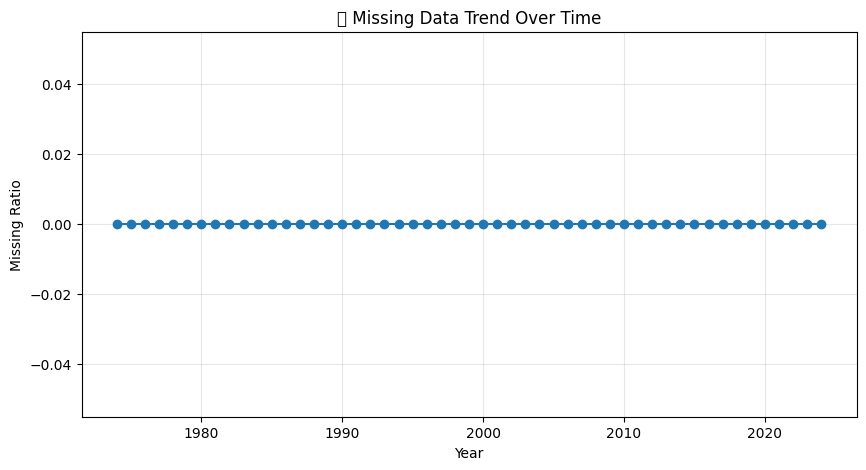

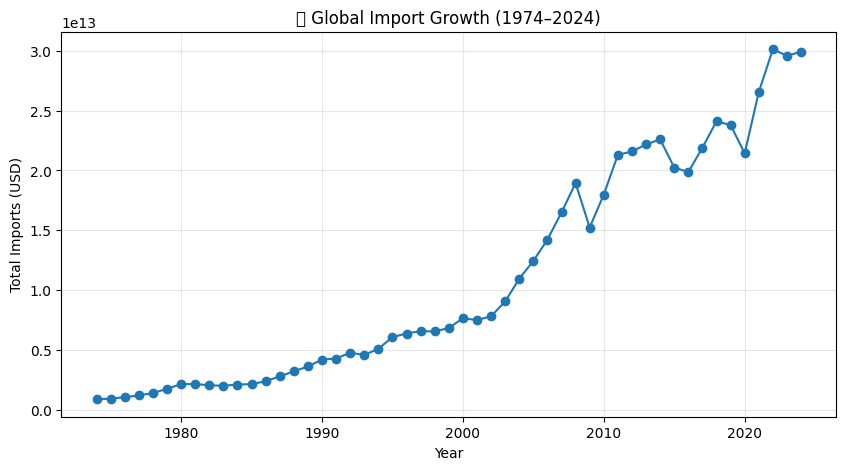

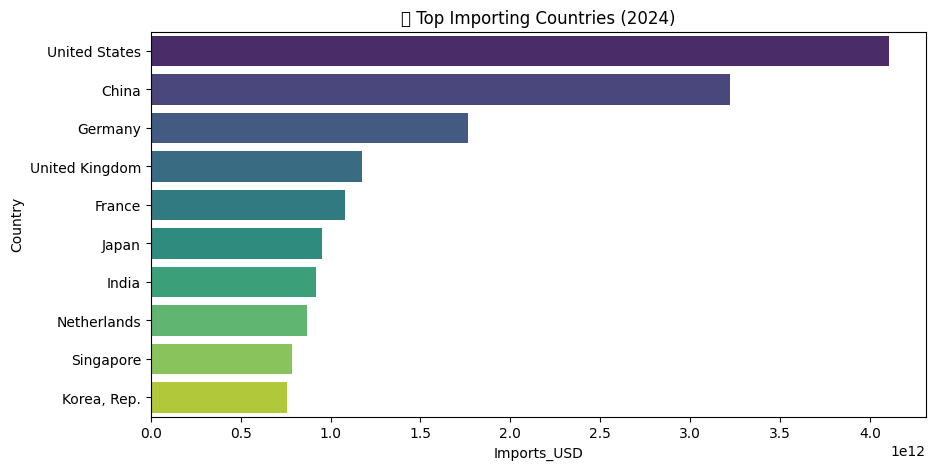

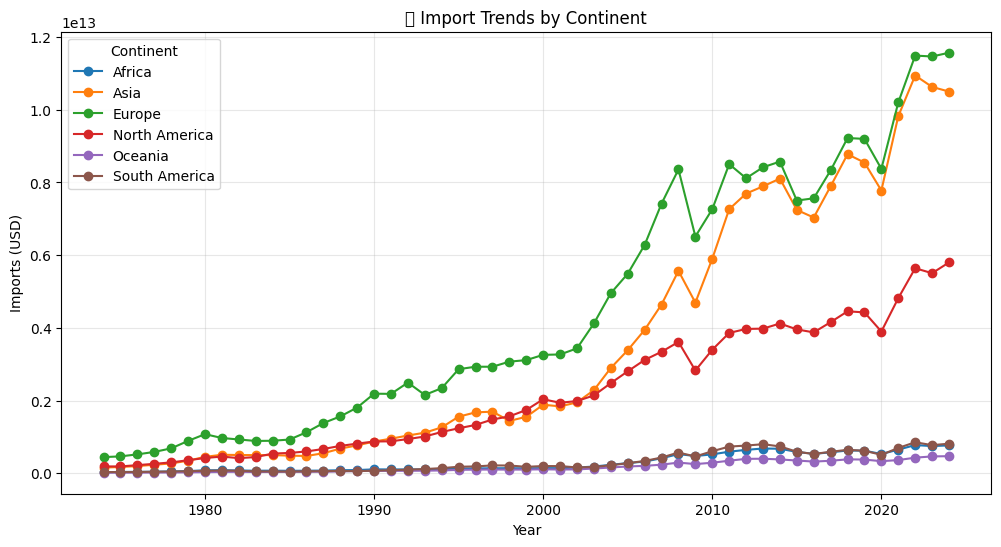

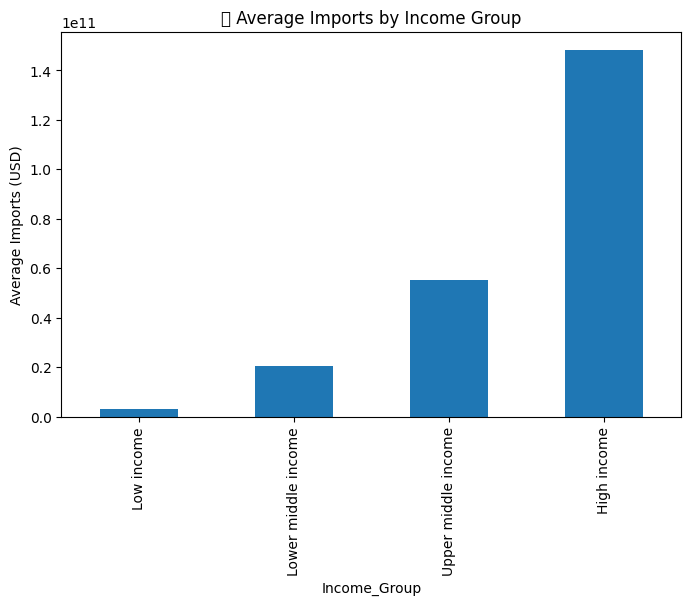

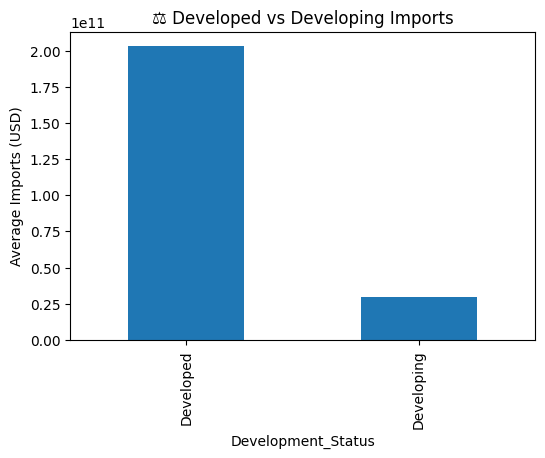

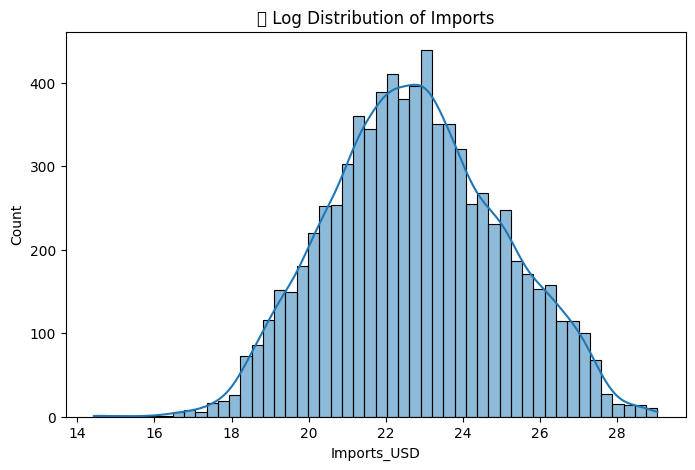

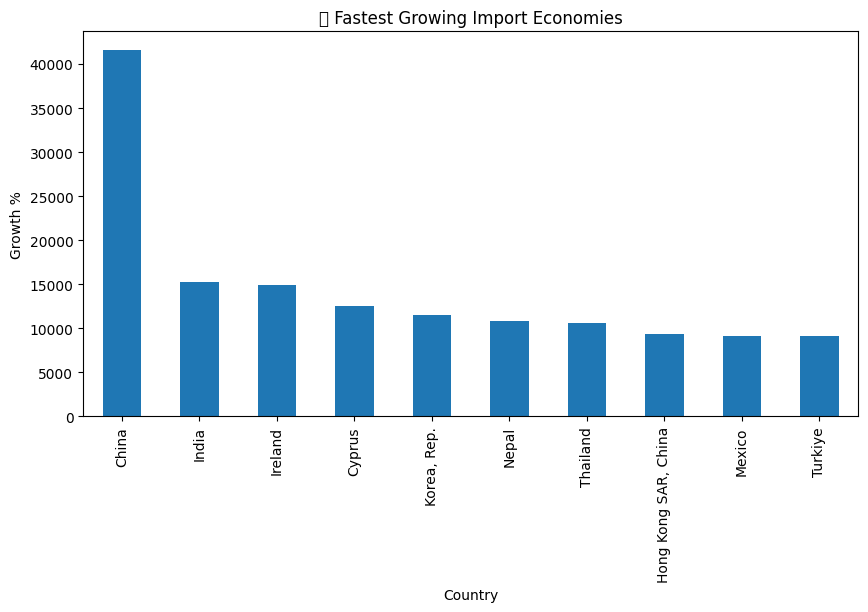

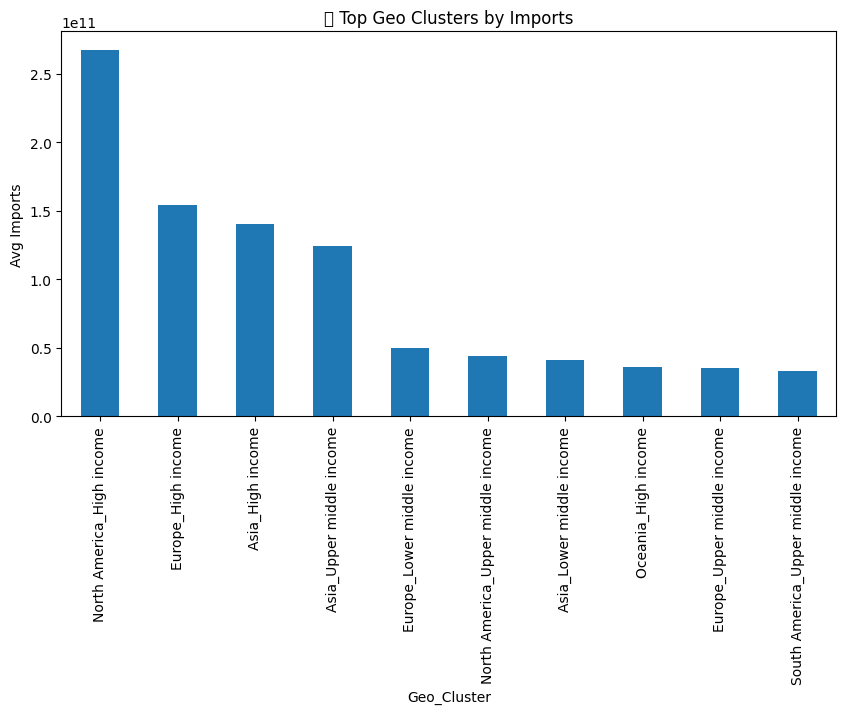

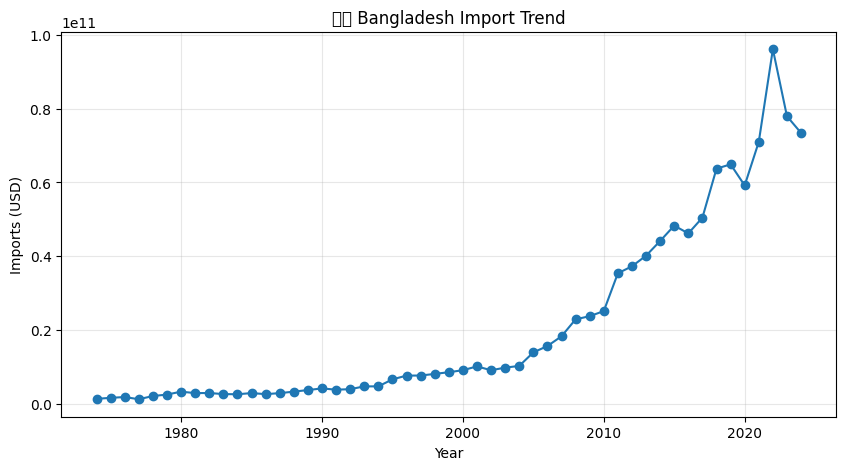

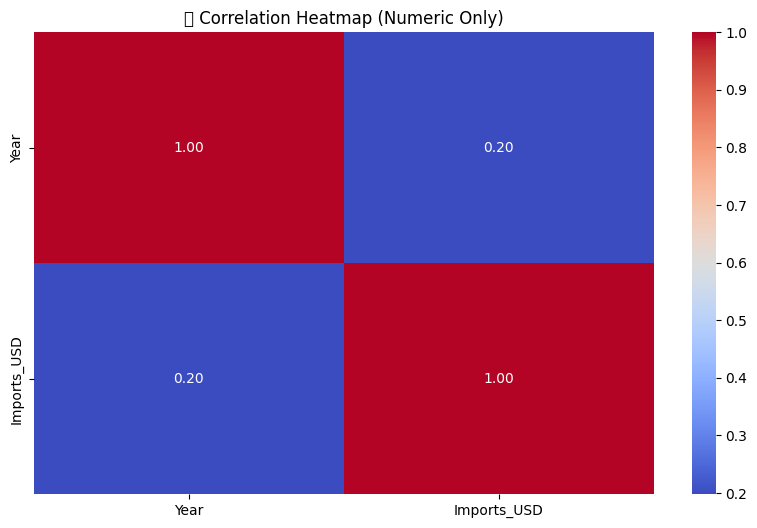

🚀 Advanced EDA Completed Successfully!


In [13]:
df.columns = df.columns.str.strip()

# Clean numeric column
df["Imports_USD"] = (
    df["Imports_Current_USD"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Imports_USD"] = pd.to_numeric(df["Imports_USD"], errors="coerce")

# Drop original column
df = df.drop(columns=["Imports_Current_USD"])

# Sort data
df = df.sort_values(["Country", "Year"])

# Drop required NaNs only
df = df.dropna(subset=["Imports_USD", "Continent"])

# Safety check
if df.empty:
    raise ValueError("Dataset is empty after cleaning.")

print("✅ Cleaned Dataset Shape:", df.shape)

# ===============================
# 📉 MISSING VALUE ANALYSIS
# ===============================
missing_trend = df.groupby("Year")["Imports_USD"].apply(lambda x: x.isna().mean())

plt.figure(figsize=(10,5))
plt.plot(missing_trend.index, missing_trend.values, marker='o')
plt.title("📉 Missing Data Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Missing Ratio")
plt.grid(alpha=0.3)
plt.show()

# ===============================
# 🌍 GLOBAL IMPORT TREND
# ===============================
global_imports = df.groupby("Year")["Imports_USD"].sum()

plt.figure(figsize=(10,5))
plt.plot(global_imports.index, global_imports.values, marker='o')
plt.title("🌍 Global Import Growth (1974–2024)")
plt.xlabel("Year")
plt.ylabel("Total Imports (USD)")
plt.grid(alpha=0.3)
plt.show()

# ===============================
# 🏆 TOP COUNTRIES (LATEST YEAR)
# ===============================
latest_year = df["Year"].max()

top_countries = (
    df[df["Year"] == latest_year]
    .dropna(subset=["Imports_USD"])
    .sort_values("Imports_USD", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x="Imports_USD", y="Country", data=top_countries, palette="viridis")
plt.title(f"🏆 Top Importing Countries ({latest_year})")
plt.show()

# ===============================
# 🌏 CONTINENT ANALYSIS
# ===============================
continent_trend = df.groupby(["Continent", "Year"])["Imports_USD"].sum().unstack()

continent_trend.T.plot(figsize=(12,6), marker='o')
plt.title("🌏 Import Trends by Continent")
plt.ylabel("Imports (USD)")
plt.grid(alpha=0.3)
plt.show()

# ===============================
# 💰 INCOME GROUP ANALYSIS
# ===============================
income_dist = df.groupby("Income_Group")["Imports_USD"].mean().sort_values()

plt.figure(figsize=(8,5))
income_dist.plot(kind="bar")
plt.title("💰 Average Imports by Income Group")
plt.ylabel("Average Imports (USD)")
plt.show()

# ===============================
# ⚖️ DEVELOPED vs DEVELOPING
# ===============================
dev_compare = df.groupby("Development_Status")["Imports_USD"].mean()

plt.figure(figsize=(6,4))
dev_compare.plot(kind="bar")
plt.title("⚖️ Developed vs Developing Imports")
plt.ylabel("Average Imports (USD)")
plt.show()

# ===============================
# 📊 DISTRIBUTION (LOG SCALE)
# ===============================
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["Imports_USD"].dropna()), bins=50, kde=True)
plt.title("📊 Log Distribution of Imports")
plt.show()

# ===============================
# 🚀 GROWTH ANALYSIS
# ===============================
growth = df.sort_values("Year").groupby("Country")["Imports_USD"].agg(["first", "last"])
growth = growth[growth["first"] > 0]

growth["growth_%"] = ((growth["last"] - growth["first"]) / growth["first"]) * 100

top_growth = growth.sort_values("growth_%", ascending=False).head(10)

plt.figure(figsize=(10,5))
top_growth["growth_%"].plot(kind="bar")
plt.title("🚀 Fastest Growing Import Economies")
plt.ylabel("Growth %")
plt.show()

# ===============================
# 🌐 GEO CLUSTER INSIGHT
# ===============================
cluster_trend = df.groupby("Geo_Cluster")["Imports_USD"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
cluster_trend.plot(kind="bar")
plt.title("🌐 Top Geo Clusters by Imports")
plt.ylabel("Avg Imports")
plt.show()

# ===============================
# 🇧🇩 BANGLADESH STORY
# ===============================
bd = df[df["Country"].str.lower() == "bangladesh"]

if not bd.empty:
    plt.figure(figsize=(10,5))
    plt.plot(bd["Year"], bd["Imports_USD"], marker="o")
    plt.title("🇧🇩 Bangladesh Import Trend")
    plt.xlabel("Year")
    plt.ylabel("Imports (USD)")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("⚠️ Bangladesh data not found.")

# ===============================
# 🔥 CORRELATION HEATMAP (FIXED)
# ===============================
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] < 2:
    print("⚠️ Not enough numeric columns for correlation.")
else:
    plt.figure(figsize=(10,6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("🔥 Correlation Heatmap (Numeric Only)")
    plt.show()

print("🚀 Advanced EDA Completed Successfully!")

## Feature engineering

Columns: ['Country', 'Year', 'Continent', 'Subregion', 'Income_Group', 'Development_Status', 'Geo_Cluster', 'Imports_USD']

Model: Logistic Regression
Accuracy: 0.8435
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       777
           1       0.84      0.85      0.84       776

    accuracy                           0.84      1553
   macro avg       0.84      0.84      0.84      1553
weighted avg       0.84      0.84      0.84      1553


Model: Decision Tree
Accuracy: 0.9704
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       777
           1       0.96      0.98      0.97       776

    accuracy                           0.97      1553
   macro avg       0.97      0.97      0.97      1553
weighted avg       0.97      0.97      0.97      1553


Model: Random Forest
Accuracy: 0.9768
              precision    recall  f1-score   support

           0       0.97      0.98      0.98  

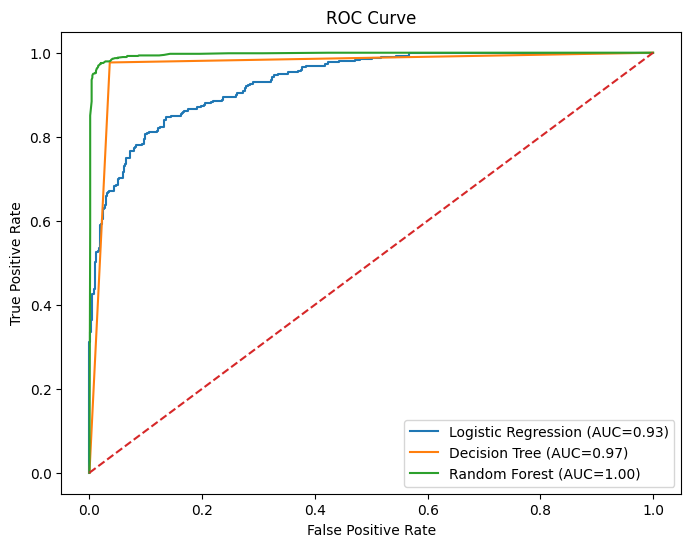

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# ===============================
# 🧹 CLEAN COLUMN NAMES
# ===============================
df.columns = df.columns.str.strip()

# 🔍 DEBUG: print columns
print("Columns:", df.columns.tolist())

# ===============================
# 🧹 HANDLE IMPORT COLUMN SAFELY
# ===============================
if "Imports_Current_USD" in df.columns:
    raw_col = "Imports_Current_USD"
elif "Imports_USD" in df.columns:
    raw_col = "Imports_USD"
else:
    raise KeyError("❌ Import column not found in dataset")

# Clean numeric values
df["Imports_USD"] = (
    df[raw_col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Imports_USD"] = pd.to_numeric(df["Imports_USD"], errors="coerce")

# Drop original column ONLY if different
if raw_col != "Imports_USD":
    df = df.drop(columns=[raw_col])

# Drop required NaNs
df = df.dropna(subset=["Imports_USD"])

# ===============================
# 🎯 TARGET CREATION
# ===============================
threshold = df["Imports_USD"].median()
df["Target"] = (df["Imports_USD"] > threshold).astype(int)

# ===============================
# 📊 FEATURES & TARGET
# ===============================
X = df.drop(["Imports_USD", "Target"], axis=1)
y = df["Target"]

# ===============================
# ✂️ TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 🔄 PREPROCESSING
# ===============================
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# ===============================
# 🤖 MODELS
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# ===============================
# 📈 TRAIN + ROC
# ===============================
plt.figure(figsize=(8,6))

for name, model in models.items():
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    print("\n======================")
    print(f"Model: {name}")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred))
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!